In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

### 1. ТЕХНІЧНА ЧАСТИНА (МАТЕМАТИКА І ВІЗУАЛІЗАЦІЯ)

In [22]:
def apply_filter(image, kernel, bias=0):
    """Математична функція згортки"""
    image_h, image_w = image.shape[:2]
    kernel_h, kernel_w = kernel.shape[:2]
    pad_h, pad_w = kernel_h // 2, kernel_w // 2
    
    # Робимо рамку (padding)
    if len(image.shape) == 3:
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='reflect')
    else:
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    output = np.zeros_like(image, dtype=np.float32)

    # Цикл згортки
    for ky in range(kernel_h):
        for kx in range(kernel_w):
            val = kernel[ky, kx]
            region = padded[ky:ky + image_h, kx:kx + image_w]
            output += region * val

    output += bias  # Додаємо зсув до всього зображення
            
    return np.clip(output, 0, 255).astype(np.uint8)

In [23]:
def show_compare(orig, filtered, title_text):
    """Малює два зображення поруч"""
    plt.figure(figsize=(12, 6))
    # Зліва - Оригінал
    plt.subplot(1, 2, 1)
    if len(orig.shape) == 3:
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(orig, cmap='gray')
    plt.title("Оригінал")
    plt.axis('off')

    # Справа - Результат
    plt.subplot(1, 2, 2)
    if len(filtered.shape) == 3:
        plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(filtered, cmap='gray')
    plt.title(title_text)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show() 

### 2. ПОЧАТОК РОБОТИ

In [24]:
img_path = 'flowers.jpg' 
output_folder = 'results'
if not os.path.exists(output_folder): os.makedirs(output_folder)

# Завантаження 
stream = open(img_path, "rb")
bytes = bytearray(stream.read())
numpyarray = np.asarray(bytes, dtype=np.uint8)
original_img = cv2.imdecode(numpyarray, cv2.IMREAD_UNCHANGED)

if original_img is None:
    print("ПОМИЛКА: Не знайдено фото! Перевірте назву файлу.")
    exit()

print(f"Фото успішно завантажено. Розмір: {original_img.shape}")

Фото успішно завантажено. Розмір: (400, 600, 3)


### 3. ВИКОНАННЯ ФІЛЬТРІВ (ЛІНІЙНО)

##### 1. ЗСУВ (SHIFT)

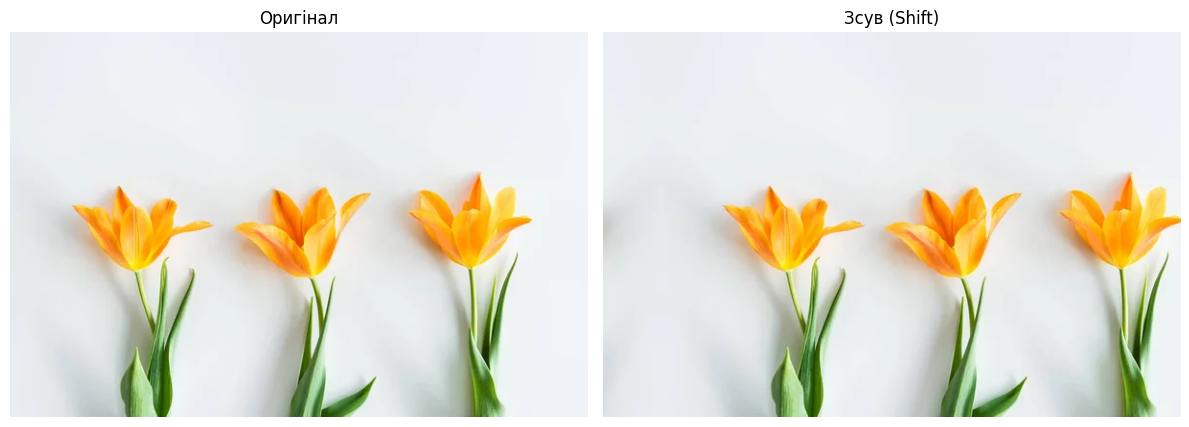

In [25]:
sh_y, sh_x = 0, 60  # Зсув по Y і X
kernel_shift = np.zeros((2 * sh_y + 1, 2 * sh_x + 1)) 
kernel_shift[0, 0] = 1  # Ставимо 1 не в центрі, а в кутку -> це зсуває зображення
res_shift = apply_filter(original_img, kernel_shift)
cv2.imwrite(f'{output_folder}/1_Shift.jpg', res_shift) # Зберігаємо
show_compare(original_img, res_shift, "Зсув (Shift)")

##### 2. ІНВЕРСІЯ (INVERSION)

2. Виконується інверсія через згортку...


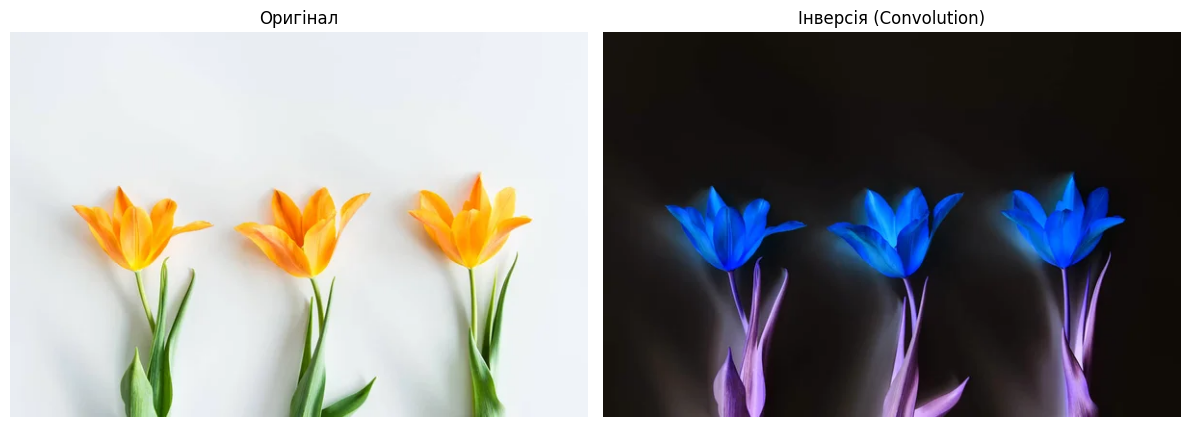

In [ ]:
kernel_inversion = np.array([[-1]])

res_inversion = apply_filter(original_img, kernel_inversion, bias=255)

cv2.imwrite(f'{output_folder}/2_Inversion.jpg', res_inversion)
show_compare(original_img, res_inversion, "Інверсія (Convolution)")

##### 3. ГАУС (GAUSSIAN BLUR)

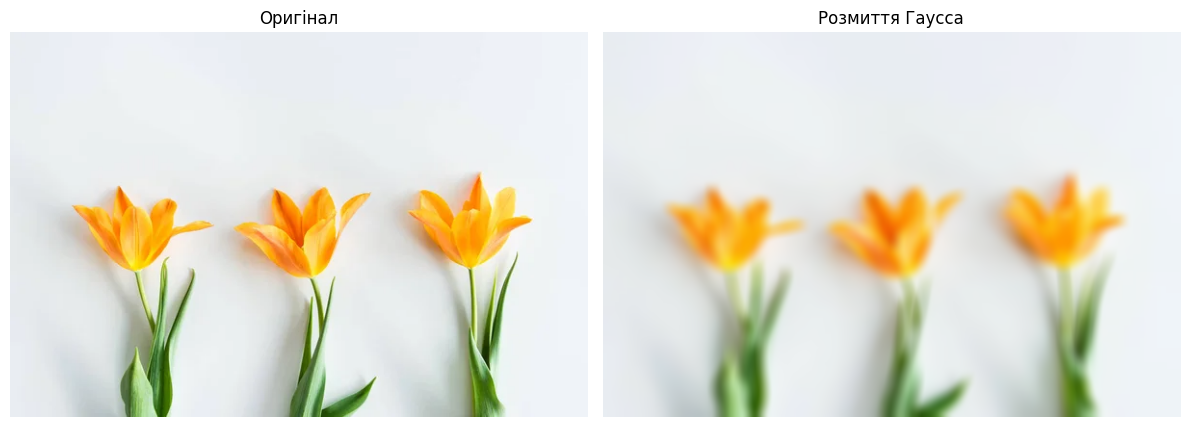

In [27]:
k_size = 15 # Розмір ядра
sigma = 6  # Сила розмиття

# Формула Гаусса
ax = np.linspace(-(k_size - 1) / 2., (k_size - 1) / 2., k_size)
gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
kernel_gauss = np.outer(gauss, gauss)
kernel_gauss = kernel_gauss / np.sum(kernel_gauss) # Нормалізація (сума має бути 1)

# Застосовуємо
res_gauss = apply_filter(original_img, kernel_gauss)
cv2.imwrite(f'{output_folder}/3_Gaussian.jpg', res_gauss)
show_compare(original_img, res_gauss, "Розмиття Гаусса")

##### 4. РУХ (MOTION BLUR)

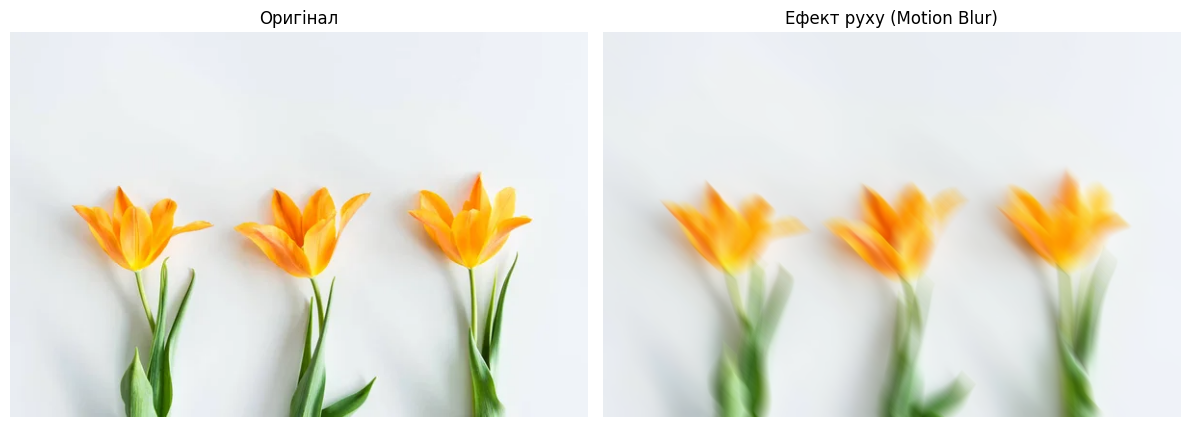

In [28]:
size = 15
kernel_motion = np.eye(size) / size
res_motion = apply_filter(original_img, kernel_motion)
cv2.imwrite(f'{output_folder}/4_Motion.jpg', res_motion)
show_compare(original_img, res_motion, "Ефект руху (Motion Blur)")

##### 5. РІЗКІСТЬ (SHARPEN) 

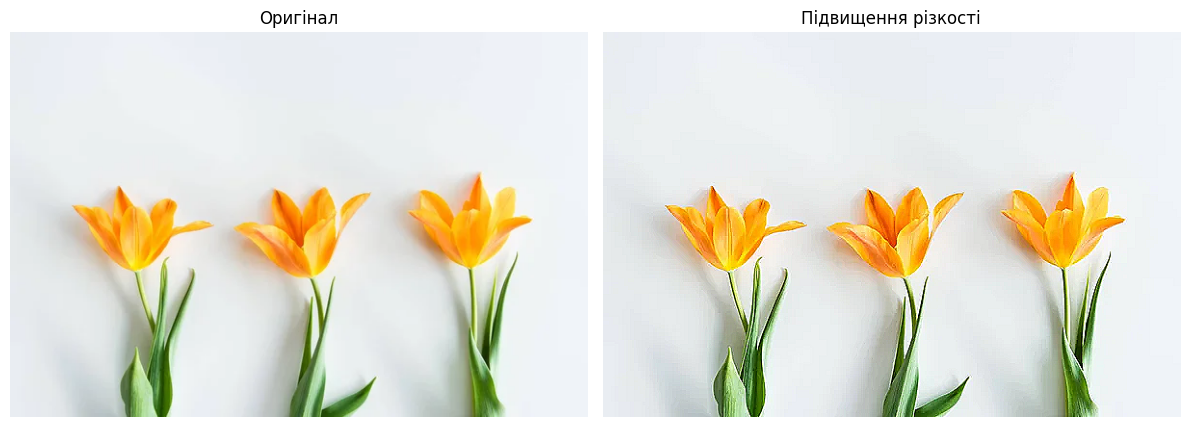

In [29]:
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
res_sharpen = apply_filter(original_img, kernel_sharpen)
cv2.imwrite(f'{output_folder}/5_Sharpen.jpg', res_sharpen)
show_compare(original_img, res_sharpen, "Підвищення різкості")

##### 6. СОБЕЛЬ (SOBEL)

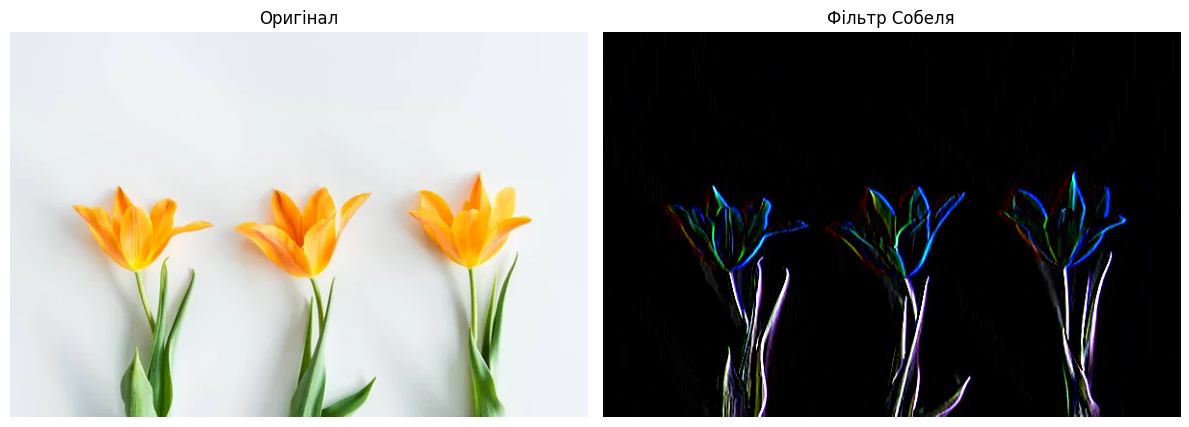

In [30]:
kernel_sobel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
res_sobel = apply_filter(original_img, kernel_sobel)
cv2.imwrite(f'{output_folder}/6_Sobel.jpg', res_sobel)
show_compare(original_img, res_sobel, "Фільтр Собеля")

##### 7. ГРАНИЦІ (EDGE DETECTION / LAPLACIAN)

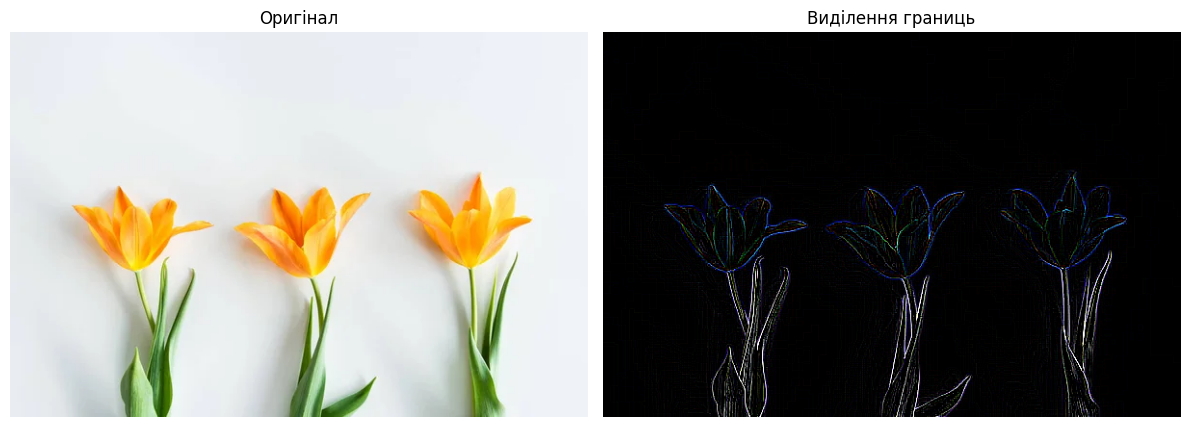

In [31]:
kernel_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])
res_edge = apply_filter(original_img, kernel_edge)
cv2.imwrite(f'{output_folder}/7_Edge.jpg', res_edge)
show_compare(original_img, res_edge, "Виділення границь")

##### 8. ТИСНЕННЯ (EMBOSS - Власний фільтр)

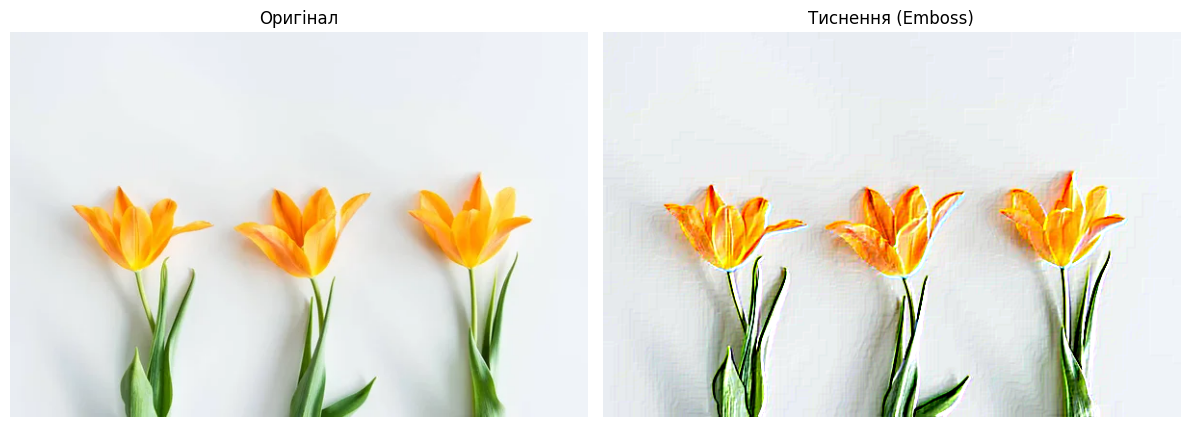

In [32]:
# Асиметричне ядро створює ефект тіні 3D
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])
res_emboss = apply_filter(original_img, kernel_emboss)
cv2.imwrite(f'{output_folder}/8_Emboss.jpg', res_emboss)
show_compare(original_img, res_emboss, "Тиснення (Emboss)")

In [33]:
print("\nВсі фільтри виконано! Результати збережено у папку 'results'.")


Всі фільтри виконано! Результати збережено у папку 'results'.
